# Co-occurrence Analysis of Book Genres in Goodreads Dataset

In [5]:
#import packages and libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
import itertools

In [6]:
#load data
df = pd.read_csv("data/GoodReads_100k_books.csv")
df.head(10)

,author,bookformat,desc,genre,img,isbn,isbn13,link,pages,rating,reviews,title,totalratings
0,Laurence M. Hauptman,Hardcover,Reveals that several hundred thousand Indians ...,"History,Military History,Civil War,American Hi...",https://i.gr-assets.com/images/S/compressed.ph...,002914180X,9.78E+12,https://goodreads.com/book/show/1001053.Betwee...,0,3.52,5,Between Two Fires: American Indians in the Civ...,33
1,"Charlotte Fiell,Emmanuelle Dirix",Paperback,Fashion Sourcebook - 1920s is the first book i...,"Couture,Fashion,Historical,Art,Nonfiction",https://i.gr-assets.com/images/S/compressed.ph...,1906863482,9.78E+12,https://goodreads.com/book/show/10010552-fashi...,576,4.51,6,Fashion Sourcebook 1920s,41
2,Andy Anderson,Paperback,The seminal history and analysis of the Hungar...,"Politics,History",https://i.gr-assets.com/images/S/compressed.ph...,948984147,9.78E+12,https://goodreads.com/book/show/1001077.Hungar...,124,4.15,2,Hungary 56,26
3,Carlotta R. Anderson,Hardcover,"""All-American Anarchist"" chronicles the life a...","Labor,History",https://i.gr-assets.com/images/S/compressed.ph...,814327079,9.78E+12,https://goodreads.com/book/show/1001079.All_Am...,324,3.83,1,All-American Anarchist: Joseph A. Labadie and ...,6
4,Jean Leveille,NaN,"Aujourdâ€™hui, lâ€™oiseau nous invite Ã sa ta...",NaN,https://i.gr-assets.com/images/S/compressed.ph...,2761920813,NaN,https://goodreads.com/book/show/10010880-les-o...,177,4.00,1,Les oiseaux gourmands,1
5,Jeffrey Pfeffer,Hardcover,Why is common sense so uncommon when it comes ...,"Business,Leadership,Romance,Historical Romance...",https://i.gr-assets.com/images/S/compressed.ph...,875848419,9.78E+12,https://goodreads.com/book/show/1001090.The_Hu...,368,3.73,7,The Human Equation: Building Profits by Puttin...,119
6,Jeffrey Pfeffer,Paperback,"""Competitive Advantage Through People"" explore...","Business,Leadership,Business,Management,Romanc...",https://i.gr-assets.com/images/S/compressed.ph...,087584717X,9.78E+12,https://goodreads.com/book/show/1001092.Compet...,304,3.65,1,Competitive Advantage Through People: Unleashi...,20
7,Edward Joesting,Paperback,"""Even if you know Hawaiian history you will fi...","History,Nonfiction",https://i.gr-assets.com/images/S/compressed.ph...,393009076,9.78E+12,https://goodreads.com/book/show/1001126.Hawaii,353,3.93,2,Hawaii: An Uncommon History,15
8,Nick Le Neve Walmsley,Paperback,At the time of her construction in the late 19...,NaN,https://i.gr-assets.com/images/S/compressed.ph...,752456830,9.78E+12,https://goodreads.com/book/show/10011431-r101,160,5.00,2,R101: A Pictorial History,3
9,"B. Alan Wallace,Dalai Lama XIV",Hardcover,"Discover your personal path to bliss,""This boo...","Religion,Buddhism,Philosophy,Spirituality,Psyc...",https://i.gr-assets.com/images/S/compressed.ph...,047146984X,9.78E+12,https://goodreads.com/book/show/100114.Genuine...,256,4.10,7,Genuine Happiness: Meditation as the Path to F...,133


In [7]:
#display the shape of the dataset
df.shape

(100000, 13)

In [8]:
#inspect the columns
df.columns

Index(['author', 'bookformat', 'desc', 'genre', 'img', 'isbn', 'isbn13',
       'link', 'pages', 'rating', 'reviews', 'title', 'totalratings'],
      dtype='object')

In [9]:
#.info() will show the data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   author        100000 non-null  object 
 1   bookformat    96772 non-null   object 
 2   desc          93228 non-null   object 
 3   genre         89533 non-null   object 
 4   img           96955 non-null   object 
 5   isbn          85518 non-null   object 
 6   isbn13        88565 non-null   object 
 7   link          100000 non-null  object 
 8   pages         100000 non-null  int64  
 9   rating        100000 non-null  float64
 10  reviews       100000 non-null  int64  
 11  title         99999 non-null   object 
 12  totalratings  100000 non-null  int64  
dtypes: float64(1), int64(3), object(9)
memory usage: 9.9+ MB


In [10]:
#select the useful columns 
df = df[['genre', 'pages', 'rating', 'reviews']]

In [11]:
#see if there are any missing values 
missing = df.isnull().sum()
missing

genre      10467
pages          0
rating         0
reviews        0
dtype: int64

In [12]:
#genre has 10467 missing values, 10% of books have no genres 
#Why will it be dropped?
df = df.dropna(subset=['genre'])
df['genre'].head()

0    History,Military History,Civil War,American Hi...
1            Couture,Fashion,Historical,Art,Nonfiction
2                                     Politics,History
3                                        Labor,History
5    Business,Leadership,Romance,Historical Romance...
Name: genre, dtype: object

In [13]:
#the genres are not in a list, rather as strings, covert to lists
df['genre'] = df['genre'].apply(lambda x: x.split(','))
df['genre'] = df['genre'].apply(lambda x: [g.strip() for g in x])
df['genre'] = df['genre'].apply(lambda x: list(set(x))) #removes any duplicates that appear in one book
df['genre'].head()

0    [History, North American Hi..., American Civil...
1      [Nonfiction, Fashion, Historical, Art, Couture]
2                                  [History, Politics]
3                                     [Labor, History]
5    [Leadership, Business, Nonfiction, Romance, Hu...
Name: genre, dtype: object

In [14]:
#there are still genres that are almost identical, so i will remove these duplicates 
df['genre'] = df['genre'].apply(lambda x: [g.strip().lower() for g in x]) #standarize into lowercase

genre_map = {
    "nurses": "nursing",
    "american revolutionary war": "american revolution",
    "tudor period": "english history",
    "sword and sorcery": "heroic fantasy",
    "lovecraftian": "cthulhu mythos",
    "gay for you": "gay romance"
}

def normalize_genres(genres):
    cleaned = []
    for g in genres:
        g = genre_map.get(g, g)  #replace if exists
        cleaned.append(g)
    return list(set(cleaned))

df['genre'] = df['genre'].apply(normalize_genres)

In [15]:
#count the number each genre appears
all_genres = [g for sublist in df['genre'] for g in sublist]
genre_counts = Counter(all_genres)

In [16]:
#number of unique genres
unique_genres = set(all_genres)
len(unique_genres)

1176

In [17]:
#generate the frequency of pairs of genre's appearing together 
pairs = []

for genres in df['genre']:
    if len(genres) > 1:
        pairs.extend(combinations(genres, 2))
pair_counts = Counter(pairs)
len(pair_counts) #numbers of pairs 

92909

In [18]:
#display the ten most common pairs
pair_counts.most_common(10)

[(('history', 'nonfiction'), 9706),
 (('fiction', 'romance'), 9159),
 (('fiction', 'fantasy'), 8676),
 (('historical', 'historical fiction'), 7127),
 (('fiction', 'historical fiction'), 6377),
 (('contemporary', 'romance'), 6241),
 (('historical', 'fiction'), 6204),
 (('paranormal', 'fantasy'), 6115),
 (('mystery', 'fiction'), 5970),
 (('cultural', 'fiction'), 5763)]

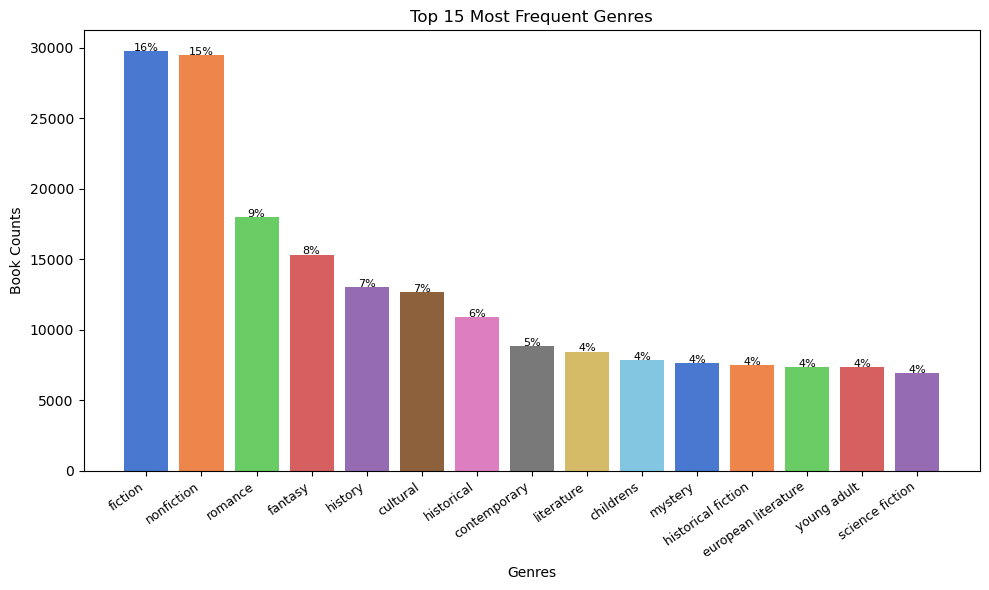

In [19]:
#get the ten top genres with teh most counts
top_genres = (pd.Series(genre_counts).sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(range(len(top_genres)), top_genres.values, color=sns.color_palette("muted", len(top_genres)))

ax.set_title("Top 15 Most Frequent Genres")
ax.set_xticks(range(len(top_genres)))
ax.set_xticklabels(top_genres.index, rotation=35, ha="right", fontsize=9)
ax.set_xlabel("Genres")
ax.set_ylabel("Book Counts")

n = sum(top_genres.values)

#add percentage text on tap of each bar 
for bar, val in zip(bars, top_genres.values):
    ax.text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 5, f"{val/n:.0%}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

In [20]:
#convert pair_counts set into DataFrame and get the top 15 genre pairs to plot
pairs_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items()],
    columns=["Genre1", "Genre2", "Count"]
)
top_pairs = pairs_df.sort_values("Count", ascending=False).head(15)
top_pairs

,Genre1,Genre2,Count
14,history,nonfiction,9706
420,fiction,romance,9159
834,fiction,fantasy,8676
327,historical,historical fiction,7127
331,fiction,historical fiction,6377
900,contemporary,romance,6241
324,historical,fiction,6204
2190,paranormal,fantasy,6115
1118,mystery,fiction,5970
319,cultural,fiction,5763


In [21]:
all_genres = [g for sub in df['genre'] for g in sub]
genre_counts = Counter(all_genres)

top_genres = [g for g, _ in genre_counts.most_common(15)]
top_genres

['fiction',
 'nonfiction',
 'romance',
 'fantasy',
 'history',
 'cultural',
 'historical',
 'contemporary',
 'literature',
 'childrens',
 'mystery',
 'historical fiction',
 'european literature',
 'young adult',
 'science fiction']

In [22]:
#create matrix for heatmap
matrix = pd.DataFrame(0, index=top_genres, columns=top_genres)
for (g1,g2), count in pair_counts.items():
    if g1 in top_genres and g2 in top_genres:

        matrix.loc[g1, g2] = count
        matrix.loc[g2, g1] = count

In [23]:
top_matrix = matrix.loc[top_genres, top_genres]
top_matrix

,fiction,nonfiction,romance,fantasy,history,cultural,historical,contemporary,literature,childrens,mystery,historical fiction,european literature,young adult,science fiction
fiction,0,0,77,1188,118,143,772,3906,69,139,118,165,225,3107,216
nonfiction,0,0,1,1,1087,4,35,42,1750,65,22,4,9,1,3
romance,77,1,0,2676,2,35,31,168,3,25,10,62,16,108,32
fantasy,1188,1,2676,0,2,9,180,417,826,211,3,94,53,265,113
history,118,1087,2,2,0,261,49,44,33,9,348,1,1,34,37
cultural,143,4,35,9,261,0,18,875,3710,36,6,46,27,4,2
historical,772,35,31,180,49,18,0,177,6,9,8,315,47,386,2
contemporary,3906,42,168,417,44,875,177,0,849,1,6,144,215,909,1
literature,69,1750,3,826,33,3710,6,849,0,5,1,57,15,1,4
childrens,139,65,25,211,9,36,9,1,5,0,5,759,51,1704,6


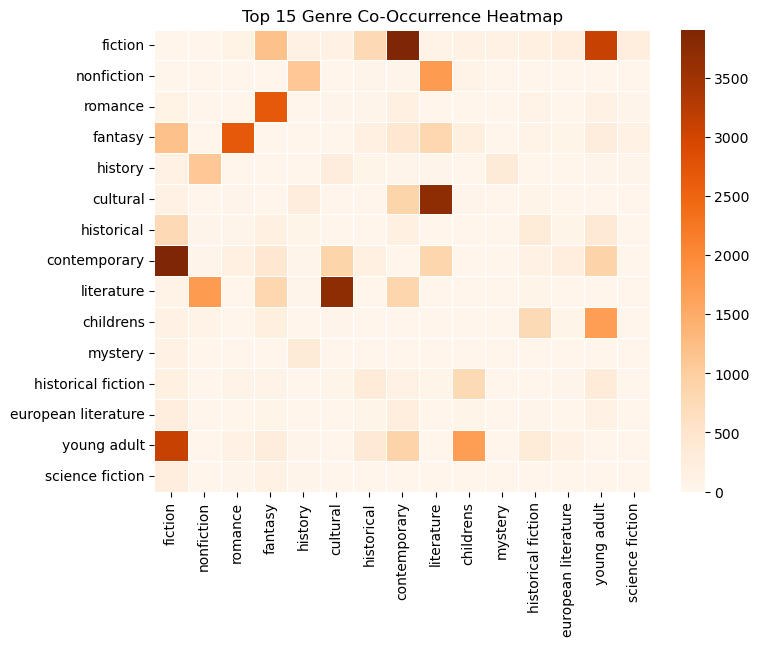

In [24]:
#Co-occurrence heat map of top genres
plt.figure(figsize=(8, 6))
sns.heatmap(top_matrix, cmap="Oranges", linewidths=0.5)
plt.title("Top 15 Genre Co-Occurrence Heatmap")
plt.show()

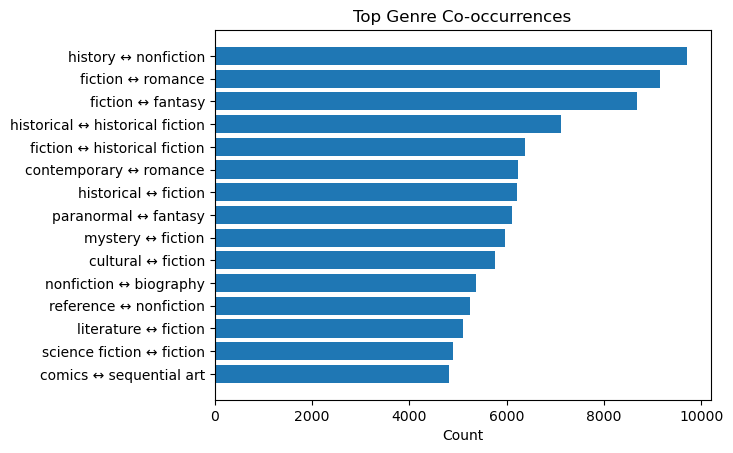

In [25]:
#bar chart that shows the top most frequent genre pairs
#bar plot of the top genre pairs 
plt.barh(top_pairs["Genre1"] + " ↔ " + top_pairs["Genre2"], top_pairs["Count"])
plt.gca().invert_yaxis()
plt.title("Top Genre Co-occurrences")
plt.xlabel("Count")
plt.show()

In [26]:
#compute metrics, support and confidence

#support-> how often two genres appear together 
total_books = len(df)
support = {
    pair: count/total_books
    for pair, count in pair_counts.items()
}
mean_support = np.mean(list(support.values()))

#confidence A->B, If A, how likely is B?
confidence_ab = {}
for (a,b), count in pair_counts.items():
    confidence_ab[(a,b)] = count / genre_counts[a]
mean_confidence_ab = np.mean(list(confidence_ab.values()))

#confidence B->A, If B, how likely is A?
confidence_ba = {}
for (a,b), count in pair_counts.items():
    confidence_ba[(b,a)] = count / genre_counts[b]
mean_confidence_ba = np.mean(list(confidence_ba.values()))

print("Support Mean: ", mean_support.round(4))
print("Confidence A->B Mean: ", mean_confidence_ab.round(4))
print("Confidence B->A Mean: ", mean_confidence_ba.round(4))

Support Mean:  0.0003
Confidence A->B Mean:  0.0466
Confidence B->A Mean:  0.0513


In [27]:
#lift -> occur more than random?
min_support = 0.001

lift = {}

for (a, b), count in pair_counts.items():
    support_ab = count / total_books
    if support_ab >= min_support:
        support_a = genre_counts[a] / total_books
        support_b = genre_counts[b] / total_books
        lift[(a, b)] = support_ab / (support_a * support_b)

In [28]:
metrics = []

common_pairs = (
    support.keys()
    & confidence_ab.keys()
    & lift.keys()
)

for pair in common_pairs:

    metrics.append({
        "Pair": pair,
        "Support": support[pair],
        "Confidence": confidence_ab[pair],
        "Lift": lift[pair]})

metrics_df = pd.DataFrame(metrics)
metrics_df.head(10)

,Pair,Support,Confidence,Lift
0,"(military fiction, adult)",0.001754,0.084318,1.198863
1,"(fantasy, young adult)",0.002960,0.017292,0.211706
2,"(writing, research)",0.001139,0.039140,6.406511
3,"(nonfiction, china)",0.002870,0.008728,1.455176
4,"(cats, animals)",0.004479,0.992574,24.761257
5,"(memoir, nature)",0.002803,0.077112,3.842004
6,"(buffy the vampire slayer, fantasy)",0.001083,0.915094,5.346241
7,"(art, theory)",0.001340,0.027624,3.658709
8,"(africa, northern africa)",0.001754,0.129218,21.035063
9,"(social work, social science)",0.001910,0.895288,127.234630


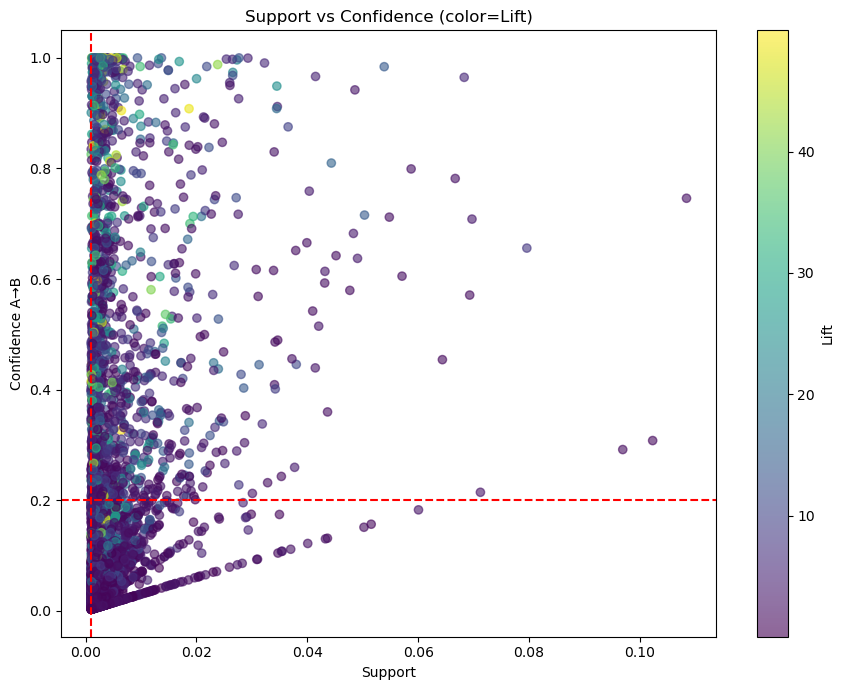

In [29]:
#Scatter plot showing relationship between Support and Confidence 
metrics_filter = metrics_df[metrics_df["Lift"] < 50] #filter
min_support = 0.001
conf_threshold = 0.2

plt.figure(figsize=(9,7))
scatter = plt.scatter(metrics_filter['Support'], metrics_filter['Confidence'], c=metrics_filter['Lift'], alpha=0.6)
plt.colorbar(scatter, label='Lift')
plt.axhline(conf_threshold, ls='--', color='r',label=f"min_support: {min_support}")
plt.axvline(min_support, ls='--', color='r', label=f"conf_threshold: {conf_threshold}")
plt.title("Support vs Confidence (color=Lift)")
plt.xlabel("Support")
plt.ylabel("Confidence A→B")
plt.tight_layout()
plt.show()

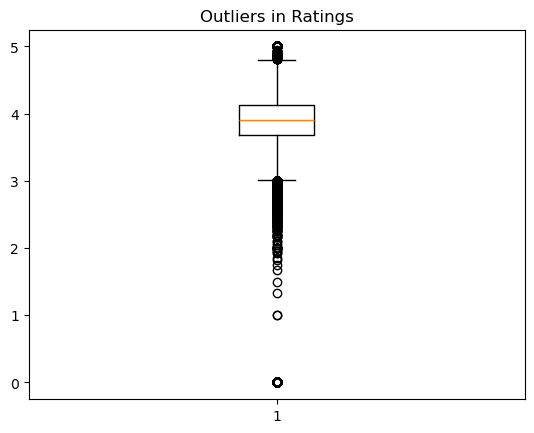

In [30]:
#outliers in ratings feature
plt.boxplot(df['rating'])
plt.title("Outliers in Ratings")
plt.show()

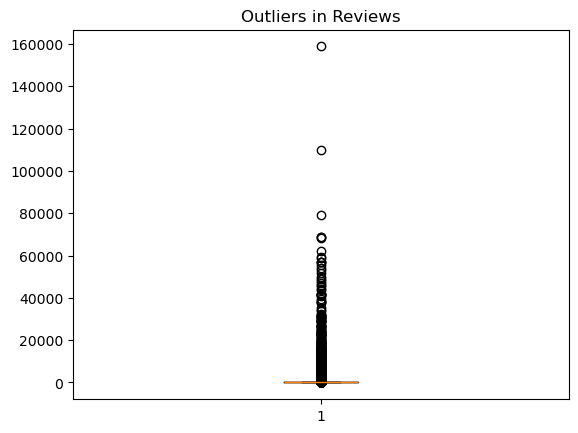

In [31]:
#outliers in review feature
plt.boxplot(df['reviews'])
plt.title("Outliers in Reviews")
plt.show()

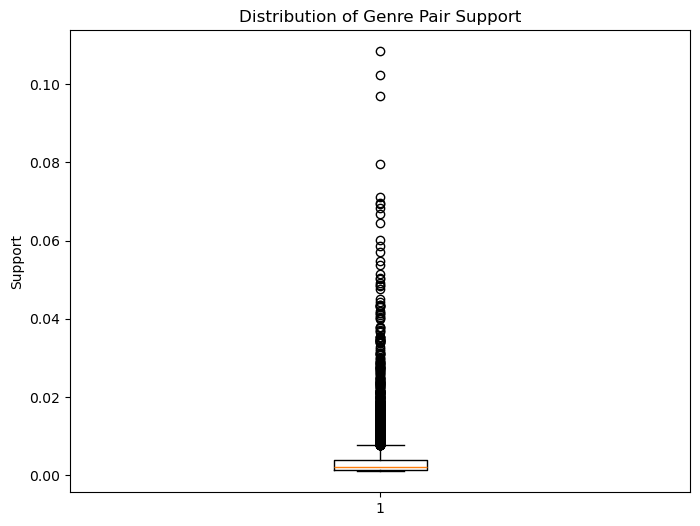

In [32]:
#bxplot showing rare genre pairs by support 
plt.figure(figsize=(8,6))
plt.boxplot(metrics_df["Support"])
plt.title("Distribution of Genre Pair Support")
plt.ylabel("Support")
plt.show()